# Credit Card Fraud Detection — Modelagem refatorada

## Objetivo

O objetivo deste notebook é treinar e comparar modelos de classificação para detecção de fraude, avaliando o desempenho diante do desbalanceamento e selecionando uma estratégia de generalização confiável.

### Etapas da modelagem

- Separação dos dados em treino, validação e holdout.
- Validação cruzada estratificada em cinco folds para preservar a proporção das classes.
- Comparação entre Logistic Regression, Random Forest e XGBoost.
- Avaliação por Average Precision, Precision, Recall, F1 e ROC-AUC.
- Aplicação de SMOTE dentro da pipeline, com StandardScaler antes do reamostramento.
- Ajuste do threshold na validação antes da avaliação final no holdout.

As rotinas repetidas de avaliação foram extraídas para src/modeling.py.

Fluxo: split → baseline dos modelos → Stratified K-Fold → SMOTE → threshold na validação → treino final → holdout.


## 1. Imports e configurações

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from xgboost import XGBClassifier

from src.modeling import (
    cross_validate_model,
    evaluate_model,
    evaluate_thresholds,
    plot_confusion_matrix,
    plot_precision_recall_curve,
)


TARGET = "Class"
RANDOM_STATE = 42

## 2. Carregamento dos dados

Execute o Jupyter a partir da raiz do projeto. O CSV deve estar em `data/raw/creditcard.csv`.


In [2]:
df = pd.read_csv("data/raw/creditcard.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Train / Validation / Holdout

In [3]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_dev,
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_holdout:", X_holdout.shape)

X_train: (182276, 30)
X_val: (45569, 30)
X_holdout: (56962, 30)


In [4]:
print("Treino")
display(y_train.value_counts())
display(y_train.value_counts(normalize=True))

print("Validação")
display(y_val.value_counts())
display(y_val.value_counts(normalize=True))

print("Holdout")
display(y_holdout.value_counts())
display(y_holdout.value_counts(normalize=True))

Treino


Class
0    181961
1       315
Name: count, dtype: int64

Class
0    0.998272
1    0.001728
Name: proportion, dtype: float64

Validação


Class
0    45490
1       79
Name: count, dtype: int64

Class
0    0.998266
1    0.001734
Name: proportion, dtype: float64

Holdout


Class
0    56864
1       98
Name: count, dtype: int64

Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64

## 4. Modelos baseline

In [5]:
models = {
    "Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=2,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=RANDOM_STATE,
        n_jobs=2,
    ),
}

## 5. Comparação inicial na validação

In [6]:
validation_results = []
model_probabilities = {}

for name, model in models.items():

    metrics = evaluate_model(
        model,
        X_train,
        y_train,
        X_val,
        y_val,
    )

    metrics.insert(0, "Model", name)
    validation_results.append(metrics)

    model_fit = clone(model)
    model_fit.fit(X_train, y_train)
    model_probabilities[name] = model_fit.predict_proba(X_val)[:, 1]

validation_df = pd.concat(validation_results, ignore_index=True)
validation_df = validation_df.sort_values(
    "average_precision",
    ascending=False,
).reset_index(drop=True)

validation_df

,Model,accuracy,precision,recall,f1,average_precision,roc_auc
0,XGBoost,0.999407,0.882353,0.759494,0.816327,0.826643,0.979300
1,Random Forest,0.999451,0.935484,0.734177,0.822695,0.811596,0.928406
2,Logistic Regression,0.998969,0.833333,0.506329,0.629921,0.708792,0.964321


### 5.1 Precision-Recall Curve

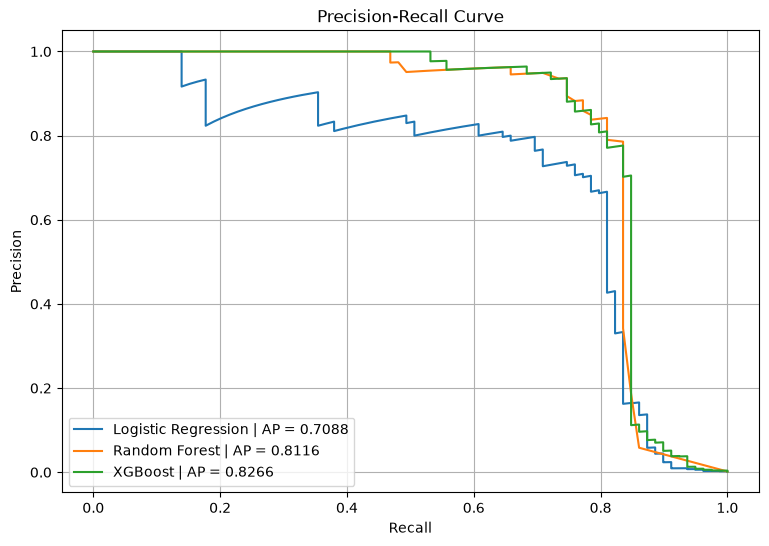

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

for name, y_proba in model_probabilities.items():

    plot_precision_recall_curve(
        y_val,
        y_proba,
        ax=ax,
        label=name,
    )

plt.show()

### 5.2 ROC Curve — complementar

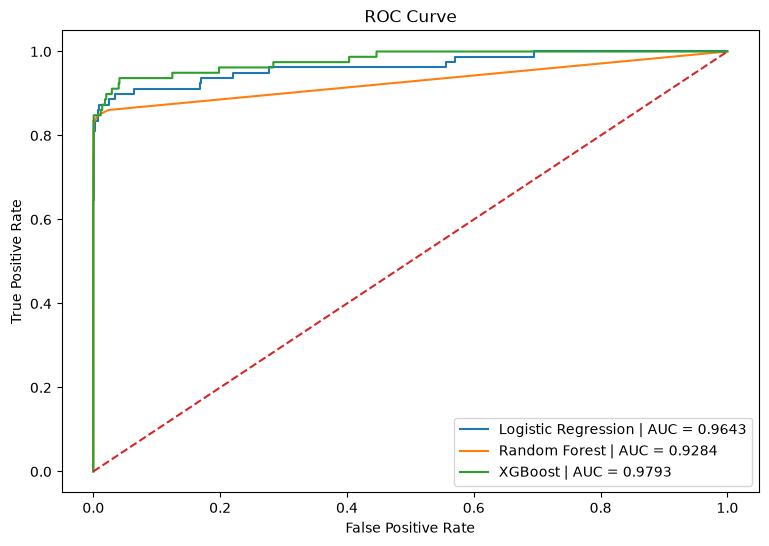

In [8]:
plt.figure(figsize=(9, 6))

for name, y_proba in model_probabilities.items():

    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc = roc_auc_score(y_val, y_proba)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} | AUC = {auc:.4f}",
    )

plt.plot([0, 1], [0, 1], "--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 6. Stratified K-Fold

A métrica principal é **Average Precision (AP)**. O objetivo aqui é verificar desempenho médio e estabilidade entre os folds.


In [9]:
cv_results = []

for name, model in models.items():

    cv = cross_validate_model(
        model,
        X_train,
        y_train,
        random_state=RANDOM_STATE,
        n_splits=5,
    )

    cv_results.append(
        {
            "Model": name,
            "AP_mean": cv["mean"],
            "AP_std": cv["std"],
            "Fold_scores": cv["fold_scores"],
        }
    )

cv_df = pd.DataFrame(cv_results)
cv_df = cv_df.sort_values("AP_mean", ascending=False).reset_index(drop=True)

cv_df

,Model,AP_mean,AP_std,Fold_scores
0,Random Forest,0.839120,0.040610,"[0.8332565634379684, 0.7768665415111898, 0.886..."
1,XGBoost,0.837354,0.031728,"[0.8087969720568137, 0.800235339230821, 0.8771..."
2,Logistic Regression,0.770436,0.050063,"[0.7356316935579726, 0.7183466926793882, 0.855..."


## 7. Experimento com SMOTE

O SMOTE deve ficar **dentro da pipeline** para ser aplicado somente ao conjunto de treino de cada fold.

Como SMOTE usa distância entre vizinhos, mantemos `StandardScaler` antes do SMOTE de forma consistente em todas as avaliações desta estratégia.

`sampling_strategy=0.1` é um ponto de partida experimental, não uma regra universal.


In [10]:
smote_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=2,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=RANDOM_STATE,
        n_jobs=2,
    ),
}

In [11]:
smote_results = []

for name, model in smote_models.items():

    smote_pipeline = ImbPipeline(
        [
            ("scaler", StandardScaler()),
            (
                "smote",
                SMOTE(
                    sampling_strategy=0.1,
                    random_state=RANDOM_STATE,
                ),
            ),
            ("model", model),
        ]
    )

    cv = cross_validate_model(
        smote_pipeline,
        X_train,
        y_train,
        random_state=RANDOM_STATE,
        n_splits=5,
    )

    smote_results.append(
        {
            "Model": name,
            "AP_mean_SMOTE": cv["mean"],
            "AP_std_SMOTE": cv["std"],
        }
    )

smote_df = pd.DataFrame(smote_results)
smote_df

,Model,AP_mean_SMOTE,AP_std_SMOTE
0,Logistic Regression,0.765507,0.050674
1,Random Forest,0.850057,0.029655
2,XGBoost,0.771760,0.048568


In [12]:
comparison_df = cv_df[
    ["Model", "AP_mean", "AP_std"]
].merge(
    smote_df,
    on="Model",
)

comparison_df["AP_diff"] = (
    comparison_df["AP_mean_SMOTE"]
    - comparison_df["AP_mean"]
)

comparison_df.sort_values(
    "AP_mean_SMOTE",
    ascending=False,
).reset_index(drop=True)

,Model,AP_mean,AP_std,AP_mean_SMOTE,AP_std_SMOTE,AP_diff
0,Random Forest,0.839120,0.040610,0.850057,0.029655,0.010937
1,XGBoost,0.837354,0.031728,0.771760,0.048568,-0.065594
2,Logistic Regression,0.770436,0.050063,0.765507,0.050674,-0.004929


## 8. Threshold — Random Forest + SMOTE

O threshold é escolhido usando **somente a validação**.

A pipeline usada aqui é a mesma estratégia avaliada no Cross Validation: `StandardScaler → SMOTE → Random Forest`.


In [13]:
rf_smote = ImbPipeline(
    [
        ("scaler", StandardScaler()),
        (
            "smote",
            SMOTE(
                sampling_strategy=0.1,
                random_state=RANDOM_STATE,
            ),
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=2,
            ),
        ),
    ]
)

rf_smote.fit(X_train, y_train)

y_proba_val = rf_smote.predict_proba(X_val)[:, 1]

threshold_results = evaluate_thresholds(
    y_val,
    y_proba_val,
)

threshold_results

,Threshold,Precision,Recall,F1
0,0.1,0.307692,0.860759,0.453333
1,0.2,0.609091,0.848101,0.708995
2,0.3,0.773810,0.822785,0.797546
3,0.4,0.840000,0.797468,0.818182
4,0.5,0.861111,0.784810,0.821192
5,0.6,0.910448,0.772152,0.835616
6,0.7,0.920635,0.734177,0.816901


In [14]:
best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_threshold_row

Threshold    0.600000
Precision    0.910448
Recall       0.772152
F1           0.835616
Name: 5, dtype: float64

### Escolha do threshold

O maior F1 pode ser usado como referência quando queremos equilibrar Precision e Recall. Em um problema real, o threshold também deve refletir custo de falso positivo e falso negativo.

Depois de escolher o threshold, não usamos o holdout para ajustá-lo novamente.


## 9. Treino final e holdout

In [15]:
FINAL_THRESHOLD = float(best_threshold_row["Threshold"])

final_model = ImbPipeline(
    [
        ("scaler", StandardScaler()),
        (
            "smote",
            SMOTE(
                sampling_strategy=0.1,
                random_state=RANDOM_STATE,
            ),
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=2,
            ),
        ),
    ]
)

final_model.fit(X_dev, y_dev)

y_proba_holdout = final_model.predict_proba(X_holdout)[:, 1]
y_pred_holdout = (y_proba_holdout >= FINAL_THRESHOLD).astype(int)

In [16]:
final_results = pd.DataFrame(
    [
        {
            "Model": "Random Forest",
            "Strategy": "StandardScaler + SMOTE 0.1",
            "Threshold": FINAL_THRESHOLD,
            "Accuracy": accuracy_score(y_holdout, y_pred_holdout),
            "Precision": precision_score(
                y_holdout,
                y_pred_holdout,
                zero_division=0,
            ),
            "Recall": recall_score(y_holdout, y_pred_holdout),
            "F1": f1_score(y_holdout, y_pred_holdout),
            "Average Precision": average_precision_score(
                y_holdout,
                y_proba_holdout,
            ),
            "ROC-AUC": roc_auc_score(
                y_holdout,
                y_proba_holdout,
            ),
        }
    ]
)

final_results

,Model,Strategy,Threshold,Accuracy,Precision,Recall,F1,Average Precision,ROC-AUC
0,Random Forest,StandardScaler + SMOTE 0.1,0.6,0.999561,0.910112,0.826531,0.86631,0.878417,0.964211


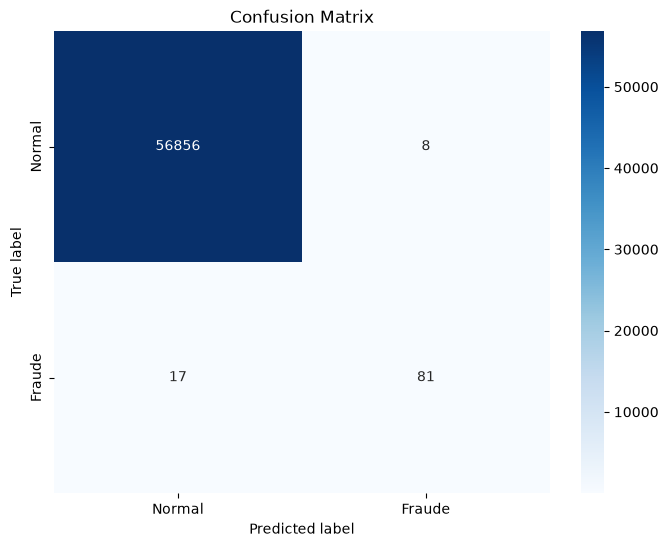

In [17]:
plot_confusion_matrix(
    y_holdout,
    y_pred_holdout,
    classes=["Normal", "Fraude"],
)

plt.show()

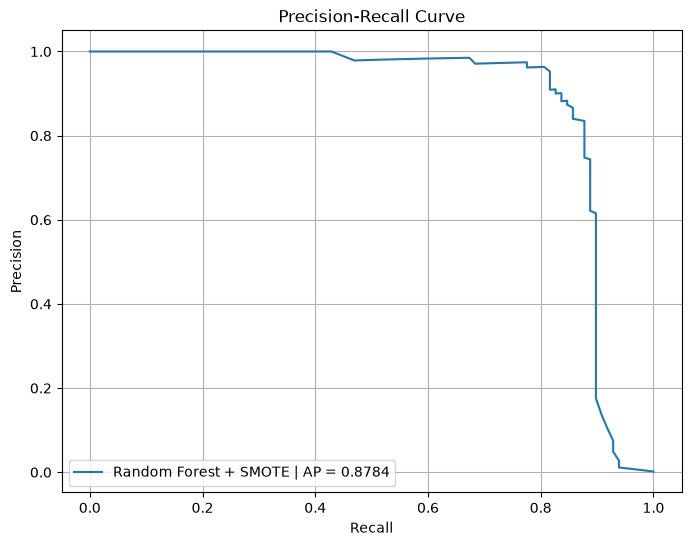

In [18]:
plot_precision_recall_curve(
    y_holdout,
    y_proba_holdout,
    label="Random Forest + SMOTE",
)

plt.show()

## 10. Resultados e conclusões


O dataset contém 284.807 transações e 31 colunas: 284.315 transações normais e 492 fraudes (0,173%). A proporção de fraudes foi preservada nas partições: treino com 182.276 transações e 315 fraudes (0,1728%), validação com 45.569 transações e 79 fraudes (0,1734%) e holdout com 56.962 transações e 98 fraudes (0,1720%).

### Comparação inicial na validação

XGBoost teve o maior Average Precision na validação (0,826643). Random Forest apresentou maior accuracy (0,999451), precision (0,935484) e F1 (0,822695) nessa partição.

### Validação cruzada: efeito de SMOTE

Em cinco folds estratificados, o AP médio do Random Forest foi 0,839120 ± 0,040610 sem SMOTE e 0,850057 ± 0,029655 com SMOTE (0,1), aumento de 0,010937. Para XGBoost, o AP caiu de 0,837354 ± 0,031728 para 0,771760 ± 0,048568; para Logistic Regression, de 0,770436 ± 0,050063 para 0,765507 ± 0,050674.

O pipeline Random Forest + SMOTE foi usado para o ajuste do threshold e a avaliação final.

### Threshold escolhido na validação

O maior F1 ocorreu em threshold = 0,6, com precision 0,910448, recall 0,772152 e F1 0,835616. O holdout não participou dessa escolha.

### Avaliação final no holdout

O modelo final foi Random Forest com StandardScaler e SMOTE (0,1), usando threshold 0,6. No holdout, obteve accuracy 0,999561, precision 0,910112, recall 0,826531, F1 0,866310, Average Precision 0,878417 e ROC-AUC 0,964211.

A matriz de confusão indica que o modelo classificou corretamente 56.856 transações normais e 81 fraudes, gerou 8 falsos positivos e deixou passar 17 fraudes.

A acurácia é alta, mas deve ser lida junto com Average Precision, precisão e recall porque a classe fraude representa apenas 0,173% do dataset.

As curvas Precision-Recall, ROC e a matriz de confusão estão exibidas nos outputs das células anteriores.

